# Zero-shot text classification


Zero-shot text classification is a NLP technique where a model classifies text into categories it hasn't been explicitly trained on. Unlike traditional classifiers that require labeled data for each target class, zero-shot models leverage pre-existing knowledge, usually from large-scale pre-trained language models like GPT or BERT. These models can understand relationships between words and concepts through pre-training and apply this understanding to new categories.

In practice, the model is given the text to classify and a set of candidate labels, often with a descriptive prompt or textual guidance that helps it infer the most appropriate category. For example, a zero-shot classifier could assign a news article to categories like "Politics" or "Sports" without prior specific training on these categories, relying instead on contextual understanding built during training. This method is valuable in cases where labeled data is scarce or impractical to obtain for every potential category.

In this tutorial, we explore one approach based on the Multilanguage Natural Language Inference Task (MNLI).

First, we load our working directory in Google Drive again.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [4]:
%cd /content/gdrive/MyDrive/TU-Ilmenau-Workshop/

/content/gdrive/MyDrive/TU-Ilmenau-Workshop


Now we load our Twitter climate protest dataset.

In [5]:
import pandas as pd

# load prediction sample
ccs_df = pd.read_csv("data/ccs-tweets_5-percent-sample.csv.gz", dtype=str) # dtype=str ensures that Twitter Ids do not get interpreted and messed up as integer values
ccs_df

,id,author.name,text,created_at,protest,tweet_type,replies,retweets,quotes,likes
0,1608975209943662592,Brochette 🇩🇪🇪🇺🇺🇦,@JoSte123 @dernaro Frage berechtigt! Die Optim...,2022-12-30,fff,reply,0,0,0,0
1,1608970951655591937,Willow Winter,Climate strike week 228. The climate crisis do...,2022-12-30,fff,retweet,6113,4593,477,76093
2,1608969658962698240,Rafael Pena 🇧🇷🇺🇸,Climate strike week 228. The climate crisis do...,2022-12-30,fff,retweet,6113,4593,477,76093
3,1608966677219401728,European Movement Oswestry,#climate 2022.12.30\n@GretaThunberg helped aut...,2022-12-30,fff,retweet,0,4,0,12
4,1608965966461014017,adina rivera,Climate strike week 228. The climate crisis do...,2022-12-30,fff,retweet,6113,4593,477,76093
...,...,...,...,...,...,...,...,...,...,...
119005,1478327911866413059,ChemieChaotin,"@TobiGotthardt Nein, die Tests sind letzte Gen...",2022-01-04,lastgen,retweet,0,4,0,33
119006,1478261613790744577,MacCop ,IKEA Symfonisk: Zweite Generation des Regal-Wi...,2022-01-04,lastgen,original,0,0,0,0
119007,1477356407288700930,Extinction Rebellion Plauen Zwickau,🌾Schaut die Neujahrsansprache der letzten Gene...,2022-01-01,lastgen,retweet,4,14,0,21
119008,1477349734008434693,@HeadSoccer@climatejustice.social,🌾Schaut die Neujahrsansprache der letzten Gene...,2022-01-01,lastgen,retweet,4,14,0,21


To save some time, let's work on a small sample of 1000 posts.

In [6]:
ccs_sample = ccs_df.sample(n=1000) # Sample 1000 random rows

# Multilingual mDeBERTa-v3-base-mnli-xnli

In zero-shot text classification, the natural language inference (NLI) can be adapted to determine whether a text belongs to a target category without specific training for that category.

The NLI task involves determining the relationship between two sentences: a premise and a hypothesis. The model’s goal is to classify the relationship as entailment (the hypothesis is true given the premise), contradiction (the hypothesis is false given the premise), or neutral (the truth of the hypothesis cannot be determined from the premise). For example, given a premise like "A person is walking a dog," and the hypothesis "Someone is outside," the relationship would be entailment.

In 2022, Moritz Laurer published an interesting transformer-based zero-shot classification model:
* The model: https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
* The corresponding paper: https://osf.io/74b8k

> This multilingual model can perform natural language inference (NLI) on 100 languages and is therefore also suitable for multilingual zero-shot classification. The underlying model was pre-trained by Microsoft on the CC100 multilingual dataset. It was then fine-tuned on the XNLI dataset, which contains hypothesis-premise pairs from 15 languages, as well as the English MNLI dataset.







# A simple example

The following code performs zero-shot text classification on a German sentence using a multilingual DeBERTa model fine-tuned for NLI.

1. It loads a zero-shot classification pipeline from the `transformers` library, specifying the model `MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`, and enables GPU processing with `device="cuda"`.
2. It defines a sentence (`sequence_to_classify`) about Angela Merkel and a list of candidate labels: "politics," "economy," "entertainment," and "environment."
3. The classifier determines which label best matches the sentence without needing training data for these specific labels.
4. The `multi_label=False` parameter indicates that the classifier should choose only one label as the best fit.

Finally, it prints the classification output, which includes the most likely label(s) and associated confidence scores.

In [7]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", device="cuda")

# basic example
sequence_to_classify = "Angela Merkel ist eine Politikerin in Deutschland und Vorsitzende der CDU"
candidate_labels = ["politics", "economy", "entertainment", "environment"]
output = classifier(sequence_to_classify, candidate_labels, multi_label=False)
print(output)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


{'sequence': 'Angela Merkel ist eine Politikerin in Deutschland und Vorsitzende der CDU', 'labels': ['politics', 'economy', 'environment', 'entertainment'], 'scores': [0.9658799171447754, 0.02284691482782364, 0.0073338947258889675, 0.003939344547688961]}


# Offensive language detection via zero-shot classification

Now we modify the code to classify our Twitter sample into the two categories from the GermEval Offensive Language Detection Task.

We split the 1000 samples into chunks of smaller batch sizes with the `chunker` function. This way, we can monitor the progress with a `tqdm` progress bar and do not overwhelm the pipeline (it tends to get stuck by very large datasets).

In [8]:
from tqdm.notebook import tqdm

def chunker(seq, size):
    return (seq[pos:pos + size] for pos in range(0, len(seq), size))

tweet_texts = ccs_sample["text"].tolist()

candidate_labels = ["offensive", "other"]
# candidate_labels = ["climate change denialism", "climate change scepticism", "climate change delayism", "climate change warning", "climate change alarmism", "other"]

all_predictions = []

# Predict labels for each tweet
batch_size = 25
for chunk in tqdm(chunker(tweet_texts, batch_size), total=int(len(tweet_texts) / batch_size)):
    output = classifier(chunk, candidate_labels, multi_label=False)
    chunk_predictions = [(x["labels"][0], x["scores"][0]) for x in output]
    all_predictions.extend(chunk_predictions)

  0%|          | 0/40 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [16]:
all_predictions

[('other', 0.9225256443023682),
 ('other', 0.8863886594772339),
 ('other', 0.8609324097633362),
 ('offensive', 0.7213725447654724),
 ('other', 0.72552889585495),
 ('other', 0.6802529692649841),
 ('offensive', 0.5045798420906067),
 ('offensive', 0.5334699749946594),
 ('other', 0.8520603179931641),
 ('other', 0.8487727642059326),
 ('other', 0.902248740196228),
 ('other', 0.5732125639915466),
 ('offensive', 0.5338308215141296),
 ('other', 0.7666438817977905),
 ('other', 0.6913375854492188),
 ('other', 0.8479804992675781),
 ('other', 0.9822152256965637),
 ('other', 0.8703168630599976),
 ('other', 0.5050926208496094),
 ('other', 0.746444046497345),
 ('other', 0.9064872860908508),
 ('other', 0.8065647482872009),
 ('other', 0.8756570219993591),
 ('other', 0.7070700526237488),
 ('other', 0.7457320690155029),
 ('other', 0.9823995232582092),
 ('other', 0.6148179769515991),
 ('other', 0.7526992559432983),
 ('other', 0.7895380854606628),
 ('other', 0.8908393383026123),
 ('other', 0.964115202426910

**Optional:** try changing the candidate labels to `["offensive", "not offensive"]`. What do you observe regarding the predicted label distribution?

This code creates a DataFrame of predictions by taking `all_predictions` (a list or array of predicted labels and scores) and assigning it to a DataFrame with the same index as `ccs_sample`. It renames the columns to "predicted_label" and "score" and then concatenates this predictions DataFrame with the original `ccs_sample` DataFrame along the columns. The result is a combined DataFrame containing the original data along with the prediction results for each entry.

In [18]:
predictions_df = pd.DataFrame(all_predictions, index=ccs_sample.index)
predictions_df.columns = ["predicted_label", "score"]
predictions_df = pd.concat([ccs_sample, predictions_df], axis=1)
predictions_df

,id,author.name,text,created_at,protest,tweet_type,replies,retweets,quotes,likes,predicted_label,score
118139,1488185123870752773,Jörg Alt SJ #Gefährder - @JoergAltSJ@mas.to,...und nun auch Stuttgart. #keinweiterso #umst...,2022-01-31,lastgen,quote,1,2,0,39,other,0.922526
110245,1526451763158597633,Paulanergarten,@Kai_Klein19XX @mal_uns @FlorianFreitag7 @DaSi...,2022-05-17,lastgen,reply,0,0,0,2,other,0.886389
107264,1539585984706351105,"svenjo heyne ,@svenjo@climatejustice.social","Mal wieder Polizeiliche Maßnahme, war als Pres...",2022-06-22,lastgen,retweet,8,38,7,71,other,0.860932
32774,1507352811830358021,FFF Bot,100 Tage 🚦 sind vorbei.\n\nStatt Sofortmaßnahm...,2022-03-25,fff,retweet,84,141,7,681,offensive,0.721373
115568,1494025526234787846,Danny,@SvenDotNet Na dann bald: Ganz Deutschland has...,2022-02-16,lastgen,reply,0,0,0,0,other,0.725529
...,...,...,...,...,...,...,...,...,...,...,...,...
117016,1490728705198592000,AutoStadtB,@LuisenstadtFoto @BSR_de @DanniPilger @Aufstan...,2022-02-07,lastgen,reply,1,0,0,2,other,0.703759
5665,1583078273793560580,illuminatus2355,@Ernstst1 @Storch_i @sciforfuture @parents4fut...,2022-10-20,fff,reply,1,0,0,0,other,0.997448
93324,1584261688341442561,Hans Yendel,Die offensichtliche Duldung der Klima-Aktionen...,2022-10-23,lastgen,retweet,15,104,0,599,other,0.575834
88952,1587342707424378880,noob_berlin(Neu Ingolstädter),@CatKatzinski @AufstandLastGen @ScientistRebel...,2022-11-01,lastgen,reply,1,0,0,0,other,0.895606


from matplotlib import pyplot as plt
predictions_df['score'].plot(kind='hist', bins=20, title='score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
predictions_df.groupby('protest').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
predictions_df.groupby('tweet_type').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
predictions_df.groupby('predicted_label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(predictions_df['protest'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(predictions_df, x='score', y='protest', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(predictions_df['tweet_type'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(predictions_df, x='score', y='tweet_type', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(predictions_df['predicted_label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(predictions_df, x='score', y='predicted_label', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

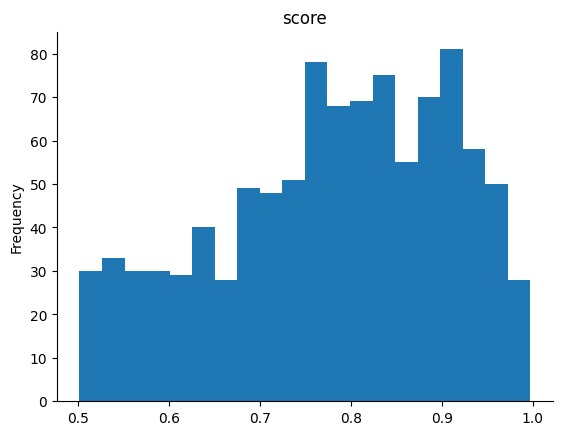

In [19]:
from matplotlib import pyplot as plt
predictions_df['score'].plot(kind='hist', bins=20, title='score')
plt.gca().spines[['top', 'right',]].set_visible(False)

Let's look at the distribution of the predicted labels.

In [10]:


label_counts = predictions_df.groupby('protest')['predicted_label'].value_counts()

label_counts

protest  predicted_label
fff      other              339
         offensive           50
lastgen  other              495
         offensive          116
Name: count, dtype: int64

We can plot the results again to get a visual impression.

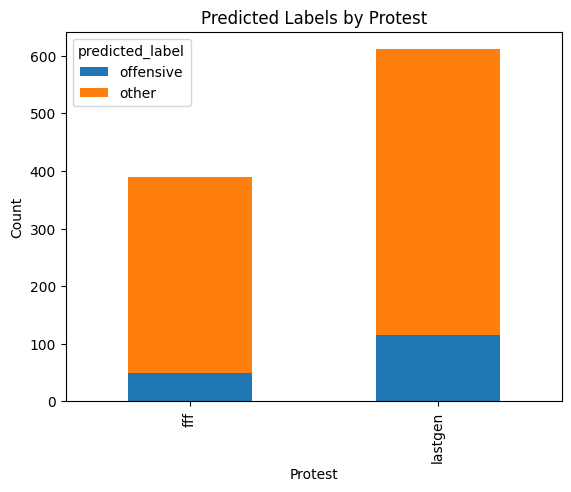

In [11]:
import matplotlib.pyplot as plt

# Assuming 'label_counts' is the Series from the previous cell
label_counts.unstack().plot(kind='bar', stacked=True)
plt.xlabel("Protest")
plt.ylabel("Count")
plt.title("Predicted Labels by Protest")
plt.show()

The relative shares of offensive and not offensive tweets seem somewhat off compared to the results from the GBERT-based classifier trained on GermEval 2018 data. Our zero-shot approach seems to overestimate the share of offensive tweets. The general trends, however, match between the two approaches (FFF occuring in less offensive contexts than Last Generation)

**What categories might work well for zero-shot classification?**
* General topics (Covid19, nuclear energy, presidential election) or sections of news (sports, economy, politics)
* Nuanced evaluations probably will not work well (e.g. ["climate change scepticism", "climate change denialism"])
* Avoid negations in category names (e.g. ["offensive", "not offensive"] will not work well)

**Idea: use zero-shot labels for candidate selection for manual coding**

We sample from predicted data candidates for manual labeling:

In [12]:

# Sample 100 "offensive" and 200 "other" rows
offensive_sample = predictions_df[predictions_df['predicted_label'] == 'offensive'].sample(n=100)
other_sample = predictions_df[predictions_df['predicted_label'] == 'other'].sample(n=200)

# Concatenate the samples
sample_df = pd.concat([offensive_sample, other_sample])

# Display or further process the sample
sample_df

,id,author.name,text,created_at,protest,tweet_type,replies,retweets,quotes,likes,predicted_label,score
83695,1588655378623238146,Luca,@Andre123456769 @AufstandLastGen Achso und das...,2022-11-04,lastgen,reply,1,0,0,0,offensive,0.865396
37778,1499011265972293636,Meik Bodo,@AfD_FraktionNRW Dummdödel Nummer zwei \n \nDi...,2022-03-02,fff,reply,0,0,0,0,offensive,0.842608
1902,1598798282670878720,Richard Weiner,"Climate strike Bergen, Norway. #FridaysForFutu...",2022-12-02,fff,retweet,84,227,15,1098,offensive,0.747751
74694,1592959814220787712,Look beyond the squirrel 🐿,@mweiss_tue @AimeevanBaalen @AufstandLastGen @...,2022-11-16,lastgen,reply,0,0,0,1,offensive,0.679154
74954,1592886057905049602,🔴SaBerlin😷♥️🖤 🇺🇦,👮‍♀️Lindner von Polizei abgeführt!👮‍♀️\n\nDenn...,2022-11-16,lastgen,retweet,263,100,61,721,offensive,0.871122
...,...,...,...,...,...,...,...,...,...,...,...,...
71603,1594763658487336978,Franz Haid,"@AufstandLastGen Jetzt sterbt endlich aus, dam...",2022-11-21,lastgen,retweet,18,70,1,1095,other,0.899440
69939,1595833189628534786,Rauschbart,Die beiden Gehirnakrobaten von #LetzteGenerati...,2022-11-24,lastgen,retweet,1110,1827,274,8778,other,0.778489
105585,1542050432150896640,tregenwulf,"@AufstandLastGen Ich bezweifle immer noch, das...",2022-06-29,lastgen,reply,0,0,0,0,other,0.766936
6625,1580159236079702017,Markus der Bayer,#FFF #FridaysForFuture #Klimaschutz #Umweltver...,2022-10-12,fff,quote,0,1,0,0,other,0.501511


Let's save the data for annotation.

In [13]:
sample_df.to_csv("data/ccs-tweets_300-sample.csv")

# Optional exercise

How does this zero-shot approach perform on the GermEval 2018 test set in terms of the common metrics precision, recall and F1-score?
1. Load the GermEval corpus
2. Predict the labels for the test set with the approach above
3. use the `classification_report` function from `sklearn`

In [14]:
# prompt: print current working directory

import os
print(os.getcwd())

/content/gdrive/MyDrive/TU-Ilmenau-Workshop


In [ ]:
%cd /content/gdrive/MyDrive/TU-Ilmenau-Workshop

/content/gdrive/MyDrive/TU-Ilmenau-Workshop


In [15]:
# load test data
import pandas as pd
df_test = pd.read_csv("data/germeval2018.test.tsv", delimiter="\t", header=None)
df_test.columns = ["text", "coarse", "fine"]
df_test

,text,coarse,fine
0,"Meine Mutter hat mir erzählt, dass mein Vater ...",OTHER,OTHER
1,@Tom174_ @davidbest95 Meine Reaktion; |LBR| Ni...,OTHER,OTHER
2,"#Merkel rollt dem Emir von #Katar, der islamis...",OTHER,OTHER
3,„Merle ist kein junges unschuldiges Mädchen“ K...,OTHER,OTHER
4,@umweltundaktiv Asylantenflut bringt eben nur ...,OFFENSE,ABUSE
...,...,...,...
3393,"@schlabonski tja, es können einen nicht alle L...",OTHER,OTHER
3394,"@RKnillmann @lawyerberlin @AfD Aha, der Islam ...",OFFENSE,ABUSE
3395,"@podilein Mannheim, weltoffen und kunterbunt. ...",OFFENSE,ABUSE
3396,@stephanweil was ist nun mit kostenlosen Kitas...,OTHER,OTHER


In [ ]:
from tqdm.notebook import tqdm

def chunker(seq, size):
    return (seq[pos:pos + size] for pos in range(0, len(seq), size))

tweet_texts = df_test["text"].tolist()

candidate_labels = ["offensive", "other"]
# candidate_labels = ["climate change denialism", "climate change scepticism", "climate change delayism", "climate change warning", "climate change alarmism", "other"]

all_predictions = []

# Predict labels for each tweet
batch_size = 25
for chunk in tqdm(chunker(tweet_texts, batch_size), total=int(len(tweet_texts) / batch_size)):
    output = classifier(chunk, candidate_labels, multi_label=False)
    chunk_predictions = [(x["labels"][0], x["scores"][0]) for x in output]
    all_predictions.extend(chunk_predictions)

  0%|          | 0/135 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
# prompt: print a classification report that compared the predicted values in all_predictions to the fine-grained labels in df_test["coarse"]. The labels in df_test_coarse need to be converted to lowercase first.

from sklearn.metrics import classification_report

# Convert labels to lowercase
test_labels = df_test["coarse"].str.lower()

# Extract predicted labels
predicted_labels = ["offense" if label == "offensive" else "other" for label, score in all_predictions]

# Generate classification report
print(classification_report(test_labels, predicted_labels))

              precision    recall  f1-score   support

     offense       0.61      0.33      0.43      1150
       other       0.72      0.89      0.80      2248

    accuracy                           0.70      3398
   macro avg       0.67      0.61      0.62      3398
weighted avg       0.69      0.70      0.67      3398



# What categories might work well for zero-shot classification?

(credits to ChatGPT)

Categories that work well for zero-shot classification are generally broad, intuitive, and conceptually distinct, allowing the model to infer relationships between text and labels based on general language knowledge. Ideal categories include:

1. **High-level topics or domains**: Labels like "politics," "technology," "health," or "entertainment" are typically well-suited, as they represent clear, commonly understood fields.

2. **Sentiment or tone**: Categories such as "positive," "negative," and "neutral" work well since sentiment is often linguistically recognizable.

3. **Emotion or intent**: Labels like "anger," "joy," "sarcasm," or "curiosity" are effective as emotional or intent-related language cues are generally distinguishable.

4. **Broad types of user intent**: For example, "question," "request," "complaint," or "praise" in customer service contexts, where linguistic patterns signal the user's intent.

5. **Product or service classifications**: Categories like "electronics," "clothing," or "home goods" often work because they are general and descriptive enough for zero-shot inference.

Categories should ideally avoid highly specific, niche distinctions or ambiguous terms, as these are harder for a model to accurately infer without direct training data.

# What types of categories might fail with zero-shot classification?

Categories that may fail with zero-shot classification tend to be highly specific, nuanced, or context-dependent, which challenges the model's ability to generalize based on language understanding alone. Such categories include:

1. **Fine-grained or domain-specific labels**: Highly technical labels (e.g., "orthogonal regression" versus "linear regression") or specific medical conditions (e.g., "arrhythmia" vs. "tachycardia") are often too detailed for the model to differentiate without explicit training.

2. **Ambiguous or overlapping categories**: Labels that are closely related or have multiple interpretations, such as "fear" versus "anxiety" or "technology" versus "innovation," can be difficult for the model to distinguish due to their nuanced overlap.

3. **Culturally specific or uncommon terms**: Niche or culturally specific categories like "Shakespearean humor" or "K-pop concepts" may not have enough grounding in the model's language pre-training to yield accurate predictions.

4. **Complex social or ethical distinctions**: Labels such as "disinformation" versus "misinformation" or "ethical" versus "moral" are often too context-dependent, as the model may lack the background knowledge needed for precise differentiation.

5. **Highly subjective categories**: Categories that depend on individual perception, like "artistic" versus "commercial" or "useful" versus "entertaining," may fail since the criteria for these labels vary widely across contexts.

These types of categories often require either additional context or specialized training data to be reliably classified.